**Merchant GMV Forecasting and Ranking**

In [41]:

import os, re, gc, json, warnings, math
from pathlib import Path
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


def find_project_root() -> Path:
    cur = Path.cwd().resolve()
    for p in [cur, *cur.parents]:
        if (p / "data" / "tables").exists():
            return p

PROJECT_ROOT = find_project_root()
TABLES_DIR = PROJECT_ROOT / "data" / "tables"
PART1_DIR = TABLES_DIR / "part_1"
CURATED_DIR = PROJECT_ROOT / "data" / "curated"
MODELS_DIR = PROJECT_ROOT / "models"
CURATED_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

TX_PARTS = ["part_2", "part_3", "part_4"]

# forecasting, variables can be tuned/altered below
WEEK_ANCHOR = "W-MON"   
HORIZON_WEEKS = 4   
TARGET_MODE = "cumulative"  
TARGET_KIND = "gmv" # revenue or gmv
HOLDOUT_ORIGINS = 6 
CV_ORIGINS = 8 
TOP_K = 100      
MIN_TRAIN_ORIGINS = 20  # weeks of history before the first CV origin

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: /Users/leopham/Documents/MAST30034_Project_2


In [42]:
# load transactions and build a merchant week panel
import pyarrow.dataset as ds

# aggregrate raw transaction to a merchant x week panel
# this will be for observed weeks only
def load_weekly_panel() -> pd.DataFrame:
    frames = []
    max_dt = pd.Timestamp.min
    for part in TX_PARTS:
        path = TABLES_DIR / part
        if not path.exists():
            print(f"  ! missing {path} - skipping")
            continue
        dataset = ds.dataset(str(path), format="parquet", partitioning="hive")
        cols = ["merchant_abn", "dollar_value", "user_id", "order_datetime"]
        tbl = dataset.to_table(columns=cols)
        df = tbl.to_pandas()
        df["order_datetime"] = pd.to_datetime(df["order_datetime"].astype(str), errors="coerce")
        df = df.dropna(subset=["order_datetime", "merchant_abn"])
        df["dollar_value"] = pd.to_numeric(df["dollar_value"], errors="coerce").fillna(0.0)

        # drop negative transactions
        df = df[df["dollar_value"] >= 0]
        max_dt = max(max_dt, df["order_datetime"].max())
        df["week"] = df["order_datetime"].dt.to_period("W-SUN").dt.start_time
        agg = df.groupby(["merchant_abn", "week"]).agg(gmv=("dollar_value", "sum"), tx_count=("dollar_value", "size"),
            unique_users=("user_id", "nunique"),).reset_index()
        frames.append(agg)
        print(f"  {part}: {len(df):,} tx -> {len(agg):,} merchant-week rows")
        del df, tbl, agg; gc.collect()

    panel = (pd.concat(frames, ignore_index=True)
               .groupby(["merchant_abn", "week"], as_index=False)
               .agg(gmv=("gmv", "sum"),
                    tx_count=("tx_count", "sum"),
                    unique_users=("unique_users", "sum")))

    # drop a trailing partial week (data can end mid-week) so it doesn't look like a GMV drop
    complete = panel["week"] + pd.Timedelta(days=6) <= max_dt.normalize()
    if (~complete).any():
        print(f"  dropping partial week(s): {sorted(panel.loc[~complete, 'week'].dt.date.unique())} "
              f"(data ends {max_dt.date()})")
    return panel[complete].reset_index(drop=True)

panel_sparse = load_weekly_panel()
print("\nSparse Panel:", panel_sparse.shape)
panel_sparse.head()

  part_2: 3,643,266 tx -> 89,803 merchant-week rows
  part_3: 4,508,106 tx -> 92,918 merchant-week rows
  part_4: 6,044,133 tx -> 121,787 merchant-week rows
  dropping partial week(s): [datetime.date(2022, 10, 24)] (data ends 2022-10-26)

Sparse Panel: (298975, 5)


,merchant_abn,week,gmv,tx_count,unique_users
0,10023283211,2021-02-22,701.566638,3,3
1,10023283211,2021-03-01,6362.419840,27,27
2,10023283211,2021-03-08,4706.012141,23,23
3,10023283211,2021-03-15,3536.843553,17,17
4,10023283211,2021-03-22,6796.619996,30,30


In [43]:
# expand to a dense merchant x week grid; 
# weeks absent for a merchant where GMV=0
def densify_panel(panel_sparse: pd.DataFrame) -> pd.DataFrame:
    all_weeks = pd.date_range(panel_sparse["week"].min(), panel_sparse["week"].max(), freq=WEEK_ANCHOR)
    first_week = panel_sparse.groupby("merchant_abn")["week"].min()
    pieces = []
    # runs from first observed week to the global last week
    for abn, fw in first_week.items():
        wk = all_weeks[all_weeks >= fw]
        pieces.append(pd.DataFrame({"merchant_abn": abn, "week": wk}))
    grid = pd.concat(pieces, ignore_index=True)
    dense = grid.merge(panel_sparse, on=["merchant_abn", "week"], how="left")
    for c in ["gmv", "tx_count", "unique_users"]:
        dense[c] = dense[c].fillna(0.0)
    dense = dense.sort_values(["merchant_abn", "week"]).reset_index(drop=True)

    # integer week index with 0 for the first global week
    week_index = {w: i for i, w in enumerate(all_weeks)}
    dense["week_idx"] = dense["week"].map(week_index).astype(int)
    return dense, all_weeks

panel, ALL_WEEKS = densify_panel(panel_sparse)
N_WEEKS = len(ALL_WEEKS)
print(f"Dense panel: {panel.shape}  |  weeks: {N_WEEKS} "
      f"({ALL_WEEKS[0].date()} .. {ALL_WEEKS[-1].date()})")
print(f"Merchants: {panel['merchant_abn'].nunique():,}")
panel.head()

Dense panel: (375161, 6)  |  weeks: 87 (2021-02-22 .. 2022-10-17)
Merchants: 4,422


,merchant_abn,week,gmv,tx_count,unique_users,week_idx
0,10023283211,2021-02-22,701.566638,3.0,3.0,0
1,10023283211,2021-03-01,6362.419840,27.0,27.0,1
2,10023283211,2021-03-08,4706.012141,23.0,23.0,2
3,10023283211,2021-03-15,3536.843553,17.0,17.0,3
4,10023283211,2021-03-22,6796.619996,30.0,30.0,4


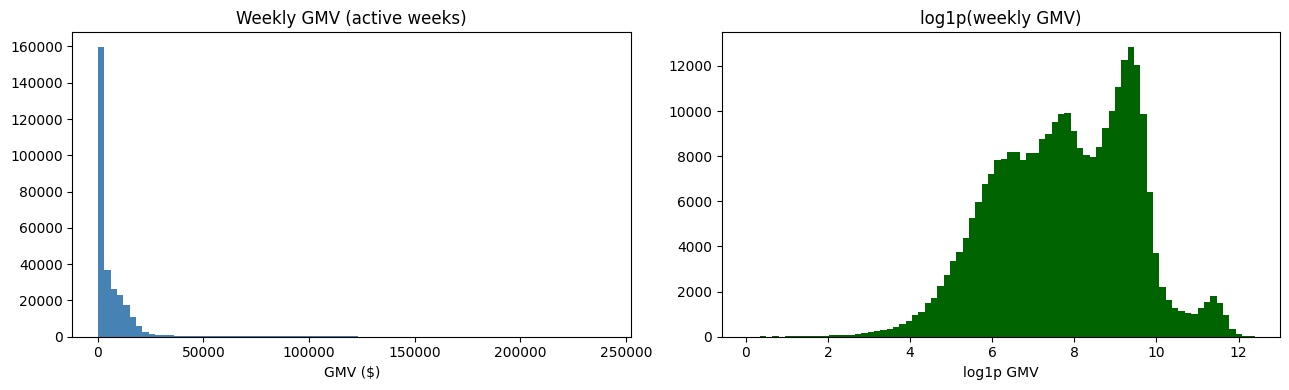

Weekly GMV Describe (Active Weeks):
count    298975.00
mean       7845.06
std       16057.96
min           0.02
50%        2541.96
90%       16250.31
99%       94878.29
max      240424.02
Name: gmv, dtype: float64

Share of merchant-weeks with zero GMV: 20.3%


In [44]:
# basic data analytics
import matplotlib.pyplot as plt

# target distribtion
active = panel.loc[panel["gmv"] > 0, "gmv"]
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(active, bins=80, color="steelblue"); ax[0].set_title("Weekly GMV (active weeks)")
ax[0].set_xlabel("GMV ($)")
ax[1].hist(np.log1p(active), bins=80, color="darkgreen"); ax[1].set_title("log1p(weekly GMV)")
ax[1].set_xlabel("log1p GMV")
plt.tight_layout(); plt.show()

print("Weekly GMV Describe (Active Weeks):")
print(active.describe(percentiles=[.5, .9, .99]).round(2))
zero_share = (panel["gmv"] == 0).mean()
print(f"\nShare of merchant-weeks with zero GMV: {zero_share:.1%}")

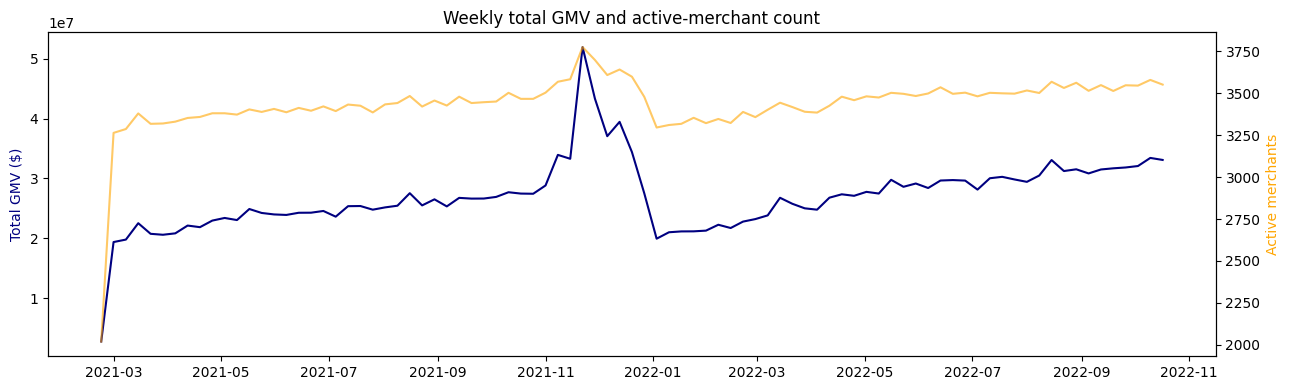

In [45]:
# aggregate gmv over time
wk = panel.groupby("week").agg(total_gmv=("gmv", "sum"), active_merchants=("merchant_abn", lambda s: (panel.loc[s.index, "gmv"] > 0).sum())).reset_index()
fig, ax1 = plt.subplots(figsize=(13, 4))
ax1.plot(wk["week"], wk["total_gmv"], color="navy", label="total GMV")
ax1.set_ylabel("Total GMV ($)", color="navy")
ax2 = ax1.twinx()
ax2.plot(wk["week"], wk["active_merchants"], color="orange", alpha=.6, label="active merchants")
ax2.set_ylabel("Active merchants", color="orange")
ax1.set_title("Weekly total GMV and active-merchant count")
plt.tight_layout(); plt.show()

In [46]:
# merchant tenure / activity
tenure = panel.groupby("merchant_abn").agg(
    weeks_present=("week_idx", "size"),
    active_weeks=("gmv", lambda s: (s > 0).sum()),
    total_gmv=("gmv", "sum"),
).reset_index()
print("Merchant tenure / activity:")
print(tenure[["weeks_present", "active_weeks", "total_gmv"]].describe().round(1))
print(f"\nMerchants active <5 weeks total: {(tenure['active_weeks'] < 5).sum():,} "
      f"({(tenure['active_weeks'] < 5).mean():.1%})  <- cold-start risk")

# GMV concentration - pareto
g = tenure["total_gmv"].sort_values(ascending=False).values
cum = np.cumsum(g) / g.sum()
print(f"Top 100 merchants hold {cum[99]:.1%} of all GMV; "
      f"top 500 hold {cum[min(499,len(cum)-1)]:.1%}.")

Merchant tenure / activity:
       weeks_present  active_weeks  total_gmv
count         4422.0        4422.0     4422.0
mean            84.8          67.6   530410.6
std              5.7          27.0  1198091.0
min             10.0           1.0     8464.1
25%             86.0          51.0    36663.9
50%             86.0          85.0   141266.7
75%             87.0          87.0   637555.0
max             87.0          87.0  9788528.0

Merchants active <5 weeks total: 90 (2.0%)  <- cold-start risk
Top 100 merchants hold 31.9% of all GMV; top 500 hold 58.5%.


In [47]:
# missing value and integrity checks
print("Nulls per column:\n", panel.isna().sum())
print("\nNegative GMV rows:", (panel["gmv"] < 0).sum())
print("Duplicated (merchant, week):", panel.duplicated(["merchant_abn", "week"]).sum())

Nulls per column:
 merchant_abn    0
week            0
gmv             0
tx_count        0
unique_users    0
week_idx        0
dtype: int64

Negative GMV rows: 0
Duplicated (merchant, week): 0


In [48]:
# static merchant attributes
# parse tags into category, revenue_band and the per-merchant take_rate
# these are time-invariant - can be used at any cutoff
def load_merchants() -> pd.DataFrame:
    m = pd.read_parquet(PART1_DIR / "tbl_merchants.parquet")
    if "merchant_abn" not in m.columns:
        m = m.reset_index()
    return m

def parse_tags(tag_str):
    """Return (category, revenue_band, take_rate). Tags look like
    '[(category words), (b), (take rate: 4.23)]' with mixed brackets/case."""
    if not isinstance(tag_str, str):
        return ("unknown", "unknown", np.nan)
    s = tag_str.strip()
    # take rate:    - last floating number in the string
    nums = re.findall(r"(\d+\.\d+)", s)
    take = float(nums[-1]) if nums else np.nan
    # revenue band - a lone single letter a-e inside brackets
    band = "unknown"
    mb = re.search(r"[\(\[]\s*([a-eA-E])\s*[\)\]]", s)
    if mb:
        band = mb.group(1).lower()
    # category - first bracketed text chunk (letters/commas/spaces, length > 2)
    cat = "unknown"
    mc = re.search(r"[\(\[]\s*([a-zA-Z][a-zA-Z ,/&'\-]{2,})", s)
    if mc:
        cat = mc.group(1).strip().lower()
    return (cat, band, take)

SEGMENT_KEYWORDS = [
    ("fashion_apparel", ["cloth", "apparel", "shoe", "fashion", "wear", "footwear", "boutique", "dress"]),
    ("electronics_tech", ["electr", "tech", "comput", "digital", "gadget", "phone", "audio", "appliance", "cable", "telecom"]),
    ("home_furniture", ["furniture", "home", "interior", "hardware", "garden", "decor", "kitchen", "bedding", "lighting", "nursery"]),
    ("health_beauty", ["health", "beauty", "cosmetic", "pharmacy", "wellness", "fitness", "medical", "optometrist", "salon", "spa"]),
]
def to_segment(cat):
    t = str(cat).lower()
    for name, kws in SEGMENT_KEYWORDS:
        if any(k in t for k in kws):
            return name
    return "luxury_specialty_other"

merchants = load_merchants()
parsed = merchants["tags"].apply(parse_tags)
merchants["category"] = parsed.apply(lambda x: x[0])
merchants["revenue_band"] = parsed.apply(lambda x: x[1])
merchants["take_rate"] = parsed.apply(lambda x: x[2])
merchants["segment"] = merchants["category"].apply(to_segment)

# fill missing take rate with the segment median
merchants["take_rate"] = (merchants.groupby("segment")["take_rate"]
                          .transform(lambda s: s.fillna(s.median())))
merchants["take_rate"] = merchants["take_rate"].fillna(merchants["take_rate"].median())

MERCHANT_STATIC = merchants[["merchant_abn", "segment", "revenue_band", "take_rate"]].copy()
print("Take rate distribution:")
print(merchants["take_rate"].describe().round(2))
print("\nSegment counts:\n", merchants["segment"].value_counts())
MERCHANT_STATIC.head()

Take rate distribution:
count    4026.00
mean        4.40
std         1.78
min         0.10
25%         2.97
50%         4.50
75%         6.03
max         7.00
Name: take_rate, dtype: float64

Segment counts:
 segment
luxury_specialty_other    1997
electronics_tech          1183
home_furniture             333
health_beauty              328
fashion_apparel            185
Name: count, dtype: int64


,merchant_abn,segment,revenue_band,take_rate
0,10023283211,electronics_tech,e,0.18
1,10142254217,electronics_tech,b,4.22
2,10165489824,luxury_specialty_other,b,4.40
3,10187291046,luxury_specialty_other,b,3.29
4,10192359162,luxury_specialty_other,a,6.33


In [49]:
# ----- Feature engineering (strictly past) and target construction -----
# For a forecast origin week t we build:
#   - Target y: GMV over weeks [t+1, t+H] (cumulative) or week t+H (single). If
#     TARGET_KIND == "revenue", multiply by the merchant take rate.
#   - Features: lags, rolling means/std/sums, trailing activity, recency, trend and
#     growth -- all computed from weeks <= t only -- plus static merchant attributes.
# One row per (merchant, origin t); keep origins where the whole target window
# exists (t + H <= last_week).
LAGS = [0, 1, 2, 3, 4, 8, 12]   # lag 0 = the origin week itself (already observed at t)
ROLL = [4, 8, 12]

def build_feature_frame(panel: pd.DataFrame) -> pd.DataFrame:
    """Create lag/rolling/recency/trend features per merchant-week (features valid AS OF that week)."""
    df = panel.sort_values(["merchant_abn", "week_idx"]).copy()
    g = df.groupby("merchant_abn", group_keys=False)

    for L in LAGS:
        df[f"gmv_lag{L}"]  = g["gmv"].shift(L)
        df[f"txn_lag{L}"]  = g["tx_count"].shift(L)
    for W in ROLL:
        # windows end at the origin week t (inclusive) - the target starts at t+1, so this is still causal
        sh = df["gmv"]
        df[f"gmv_rollmean{W}"] = sh.groupby(df["merchant_abn"]).rolling(W, min_periods=1).mean().reset_index(level=0, drop=True)
        df[f"gmv_rollsum{W}"]  = sh.groupby(df["merchant_abn"]).rolling(W, min_periods=1).sum().reset_index(level=0, drop=True)
        df[f"gmv_rollstd{W}"]  = sh.groupby(df["merchant_abn"]).rolling(W, min_periods=2).std().reset_index(level=0, drop=True)
        shu = df["unique_users"]
        df[f"users_rollmean{W}"] = shu.groupby(df["merchant_abn"]).rolling(W, min_periods=1).mean().reset_index(level=0, drop=True)

    # Recency / tenure
    df["tenure_weeks"] = g.cumcount()                      # weeks since first appearance
    active = (df["gmv"] > 0).astype(int)
    df["active_lag1"] = g["gmv"].shift(1).gt(0).astype(float)
    df["active_ratio_8"] = (active.groupby(df["merchant_abn"]).rolling(8, min_periods=1).mean()
                            .reset_index(level=0, drop=True))
    # Weeks since last active week as of t (0 if active in week t)
    def weeks_since_active(s):
        out, last = [], np.nan
        for i, v in enumerate(s.values):
            if v > 0:
                last = i
            out.append(np.nan if np.isnan(last) else (i - last))
        return pd.Series(out, index=s.index)
    df["weeks_since_active"] = g["gmv"].apply(weeks_since_active)

    # Trend: recent 4w mean vs previous 4w mean (growth), and 8-week OLS slope
    df["growth_4_4"] = (df["gmv_rollmean4"] + 1) / (
        g["gmv"].shift(4).groupby(df["merchant_abn"]).rolling(4, min_periods=1).mean()
        .reset_index(level=0, drop=True) + 1)

    # Calendar features of the ORIGIN week
    wk = pd.to_datetime(df["week"])
    df["woy"]   = wk.dt.isocalendar().week.astype(int)
    df["month"] = wk.dt.month.astype(int)
    df["sin_woy"] = np.sin(2*np.pi*df["woy"]/52.0)
    df["cos_woy"] = np.cos(2*np.pi*df["woy"]/52.0)

    # Same-week-last-year GMV (52w lag), for the "seasonal naive" baseline & as a feature
    df["gmv_lag52"] = g["gmv"].shift(52)
    return df

feat = build_feature_frame(panel)
feat = feat.merge(MERCHANT_STATIC, on="merchant_abn", how="left")
print("Feature frame:", feat.shape)
feat.filter(regex="gmv_lag1$|gmv_rollmean4|tenure_weeks|weeks_since_active|take_rate").head()

Feature frame: (375161, 45)


,gmv_lag1,gmv_rollmean4,tenure_weeks,weeks_since_active,take_rate
0,NaN,701.566638,0,0,0.18
1,701.566638,3531.993239,1,0,0.18
2,6362.419840,3923.332873,2,0,0.18
3,4706.012141,3826.710543,3,0,0.18
4,3536.843553,5350.473883,4,0,0.18


In [50]:
def _forward_window_sum(vals: np.ndarray, h: int) -> np.ndarray:
    """y[i] = sum(vals[i+1 : i+1+h]); NaN when the full window runs past the series end.

    The merchant's dense weekly series is contiguous, so a prefix-sum gives the next-h-weeks
    total in O(n). Requires the whole window to exist (no partial windows)."""
    n = len(vals)
    csum = np.concatenate([[0.0], np.cumsum(vals)])
    y = np.full(n, np.nan)
    idx = np.arange(n)
    valid = idx <= (n - 1 - h)   # full window i+1 .. i+h must fit in the series
    starts = idx + 1
    ends = idx + 1 + h
    y[valid] = csum[ends[valid]] - csum[starts[valid]]
    return y

def add_target(feat: pd.DataFrame) -> pd.DataFrame:
    """Attach the forward-looking target y for each origin week t (per merchant)."""
    df = feat.sort_values(["merchant_abn", "week_idx"]).copy()
    if TARGET_MODE == "single":
        y = df.groupby("merchant_abn", group_keys=False)["gmv"].shift(-HORIZON_WEEKS)
        df["y_gmv"] = y.to_numpy()
    else:  # cumulative sum over weeks t+1 .. t+H
        parts = []
        for _, sub in df.groupby("merchant_abn", sort=False):
            parts.append(pd.Series(_forward_window_sum(sub["gmv"].to_numpy(), HORIZON_WEEKS),
                                   index=sub.index))
        df["y_gmv"] = pd.concat(parts).reindex(df.index).to_numpy()
    df["y"] = df["y_gmv"] * df["take_rate"] / 100 if TARGET_KIND == "revenue" else df["y_gmv"]
    return df

feat = add_target(feat)
# Keep only rows with an observed target window.
samples = feat[feat["y"].notna()].copy()
print(f"Samples with target: {len(samples):,}  across "
      f"{samples['week_idx'].nunique()} origin weeks "
      f"({samples['week_idx'].min()}..{samples['week_idx'].max()})")
samples[["merchant_abn","week","week_idx","gmv","y"]].head()

Samples with target: 357,473  across 83 origin weeks (0..82)


,merchant_abn,week,week_idx,gmv,y
0,10023283211,2021-02-22,0,701.566638,21401.895531
1,10023283211,2021-03-01,1,6362.419840,21645.492001
2,10023283211,2021-03-08,2,4706.012141,22751.003967
3,10023283211,2021-03-15,3,3536.843553,24066.085361
4,10023283211,2021-03-22,4,6796.619996,27034.290151


In [51]:
FEATURE_COLS = (
    [f"gmv_lag{L}" for L in LAGS] +
    [f"txn_lag{L}" for L in LAGS] +
    [f"gmv_rollmean{W}" for W in ROLL] +
    [f"gmv_rollsum{W}"  for W in ROLL] +
    [f"gmv_rollstd{W}"  for W in ROLL] +
    [f"users_rollmean{W}" for W in ROLL] +
    ["gmv_lag52", "tenure_weeks", "active_lag1", "active_ratio_8",
     "weeks_since_active", "growth_4_4", "woy", "month", "sin_woy", "cos_woy",
     "take_rate"]
)
CAT_COLS = ["segment", "revenue_band"]

# one hot encoding for categoricals
# NaN values are filled with 0
X_all = samples[FEATURE_COLS].copy()
X_all = X_all.replace([np.inf, -np.inf], np.nan).fillna(0.0)
cat_dummies = pd.get_dummies(samples[CAT_COLS].astype(str), prefix=CAT_COLS)
X_all = pd.concat([X_all.reset_index(drop=True), cat_dummies.reset_index(drop=True)], axis=1)
MODEL_FEATURES = X_all.columns.tolist()

y_all = samples["y"].to_numpy()
y_log = np.log1p(np.clip(y_all, 0, None))     # model in log space - heavy tail
origin_all = samples["week_idx"].to_numpy()
abn_all = samples["merchant_abn"].to_numpy()
print("Design matrix:", X_all.shape, "- features:", len(MODEL_FEATURES))

Design matrix: (357473, 49) - features: 49


In [52]:
from scipy.stats import spearmanr
from sklearn.metrics import ndcg_score, mean_absolute_error, mean_squared_error

ROLL_BASE = 4

def ndcg_at_k(y_true, y_score, k):
    if len(y_true) < 2:
        return np.nan
    return ndcg_score(np.asarray(y_true).reshape(1, -1),
                      np.asarray(y_score).reshape(1, -1), k=k)

def rank_metrics(y_true, y_pred):
    """Ranking + error metrics for one origin (one set of merchants)."""
    out = {}
    if len(np.unique(y_true)) > 1 and len(y_true) > 2:
        out["spearman"] = spearmanr(y_true, y_pred).correlation
    else:
        out["spearman"] = np.nan
    out["ndcg@100"] = ndcg_at_k(y_true, y_pred, min(TOP_K, len(y_true)))
    out["ndcg@10"]  = ndcg_at_k(y_true, y_pred, min(10, len(y_true)))
    out["mae"]  = mean_absolute_error(y_true, y_pred)
    out["rmse"] = mean_squared_error(y_true, y_pred) ** 0.5
    return out

def evaluate_by_origin(df_idx, y_true, y_pred):
    """Average per-origin metrics over the origins present in df_idx."""
    res = []
    for c in np.unique(df_idx):
        m = df_idx == c
        if m.sum() < 3:
            continue
        res.append(rank_metrics(y_true[m], y_pred[m]))
    r = pd.DataFrame(res)
    return r.mean(numeric_only=True)

In [53]:
# ---- Baseline predictions straight from the feature frame (no fitting needed) ----
H = HORIZON_WEEKS
mult = H if TARGET_MODE == "cumulative" else 1
baseline_cols = {
    "last_value":   samples["gmv_lag0"].fillna(0).to_numpy() * mult,
    "rolling_mean": samples[f"gmv_rollmean{ROLL_BASE}"].fillna(0).to_numpy() * mult,
    "seasonal_naive": (samples["gmv_lag52"].fillna(0).to_numpy() *
                       (mult if TARGET_MODE == "cumulative" else 1)),
}
if TARGET_KIND == "revenue":
    tr = samples["take_rate"].to_numpy() / 100
    baseline_cols = {k: v * tr for k, v in baseline_cols.items()}
print("Baselines ready:", list(baseline_cols))

Baselines ready: ['last_value', 'rolling_mean', 'seasonal_naive']


In [54]:
# defining time based folds
origins_sorted = np.sort(samples["week_idx"].unique())
holdout_origins = origins_sorted[-HOLDOUT_ORIGINS:]
dev_origins     = origins_sorted[:-HOLDOUT_ORIGINS]

cv_candidates = dev_origins[dev_origins >= (origins_sorted[0] + MIN_TRAIN_ORIGINS)]
cv_val_origins = cv_candidates[np.linspace(0, len(cv_candidates)-1, CV_ORIGINS).astype(int)] \
                 if len(cv_candidates) >= CV_ORIGINS else cv_candidates

def fold_masks(val_origin):
    train = origin_all <= (val_origin - H)      # targets fully observed before val origin
    val   = origin_all == val_origin
    return train, val

print("Dev Origins:", dev_origins.min(), "..", dev_origins.max()),
print()
print("CV Val Origins:", list(cv_val_origins))
print("Holdout Origins:", list(holdout_origins))

Dev Origins: 0 .. 76

CV Val Origins: [np.int64(20), np.int64(28), np.int64(36), np.int64(44), np.int64(52), np.int64(60), np.int64(68), np.int64(76)]
Holdout Origins: [np.int64(77), np.int64(78), np.int64(79), np.int64(80), np.int64(81), np.int64(82)]


In [ ]:
# XG boost regression
import xgboost as xgb

def cv_score_regressor(params, num_rounds):
    rows = []
    for c in cv_val_origins:
        tr_m, va_m = fold_masks(c)
        if tr_m.sum() < 1000 or va_m.sum() < 3:
            continue
        dtr = xgb.DMatrix(X_all.values[tr_m], label=y_log[tr_m])
        dva = xgb.DMatrix(X_all.values[va_m])
        bst = xgb.train(params, dtr, num_boost_round=num_rounds, verbose_eval=False)
        pred = np.expm1(bst.predict(dva))
        rows.append(rank_metrics(y_all[va_m], pred))
    r = pd.DataFrame(rows).mean(numeric_only=True)
    return r

base_params = dict(objective="reg:squarederror", eval_metric="rmse", seed=RANDOM_STATE, tree_method="hist")
grid = [
    dict(max_depth=5, eta=0.05, subsample=0.8, colsample_bytree=0.8, min_child_weight=5),
    dict(max_depth=6, eta=0.05, subsample=0.8, colsample_bytree=0.8, min_child_weight=10),
    dict(max_depth=7, eta=0.03, subsample=0.7, colsample_bytree=0.7, min_child_weight=20),
    dict(max_depth=4, eta=0.08, subsample=0.9, colsample_bytree=0.9, min_child_weight=5),
]
results = []
for gp in grid:
    params = {**base_params, **gp}
    sc = cv_score_regressor(params, num_rounds=400)
    results.append({**gp, **sc.to_dict()})
cv_tbl = pd.DataFrame(results).sort_values("spearman", ascending=False)
print("Regression CV (mean over folds):")
display(cv_tbl.round(4))
best_reg = {**base_params, **{k: cv_tbl.iloc[0][k] for k in grid[0]}}
best_reg["max_depth"] = int(best_reg["max_depth"]); best_reg["min_child_weight"] = int(best_reg["min_child_weight"])
print("Best regression params:", best_reg)

In [ ]:
# XG boost ranking
# ranking objective optimises order directly. 
# each forecast origin is a query group 
def make_groups(mask):
    """Return group sizes (per origin) in the order rows appear, for XGBoost ranking."""
    o = origin_all[mask]
    order = np.argsort(o, kind="stable")
    sizes = pd.Series(o[order]).value_counts(sort=False).reindex(np.unique(o)).values
    return order, sizes

def cv_score_ranker(params, num_rounds):
    rows = []
    for c in cv_val_origins:
        tr_m, va_m = fold_masks(c)
        if tr_m.sum() < 1000 or va_m.sum() < 3:
            continue
        order, sizes = make_groups(tr_m)
        Xtr = X_all.values[tr_m][order]
        # relevance labels - integer gains from GMV quantile buckets
        ytr = y_all[tr_m][order]
        otr = origin_all[tr_m][order]
        rel = np.zeros(len(ytr))
        for cc in np.unique(otr):
            mm = otr == cc
            rel[mm] = pd.qcut(ytr[mm].argsort().argsort(), q=min(32, mm.sum()),
                              labels=False, duplicates="drop")
        dtr = xgb.DMatrix(Xtr, label=rel); dtr.set_group(sizes)
        dva = xgb.DMatrix(X_all.values[va_m])
        bst = xgb.train(params, dtr, num_boost_round=num_rounds, verbose_eval=False)
        pred = bst.predict(dva)
        rows.append(rank_metrics(y_all[va_m], pred))
    return pd.DataFrame(rows).mean(numeric_only=True)

rank_base = dict(objective="rank:ndcg", eval_metric="ndcg@100",
                 seed=RANDOM_STATE, tree_method="hist")
rank_grid = [
    dict(max_depth=6, eta=0.05, subsample=0.8, colsample_bytree=0.8, min_child_weight=5),
    dict(max_depth=5, eta=0.05, subsample=0.8, colsample_bytree=0.8, min_child_weight=10),
    dict(max_depth=7, eta=0.03, subsample=0.7, colsample_bytree=0.7, min_child_weight=10),
]
rank_results = []
for gp in rank_grid:
    params = {**rank_base, **gp}
    sc = cv_score_ranker(params, num_rounds=400)
    rank_results.append({**gp, **sc.to_dict()})
rank_tbl = pd.DataFrame(rank_results).sort_values("ndcg@100", ascending=False)
print("Ranking CV (mean over folds):")
display(rank_tbl.round(4))
best_rank = {**rank_base, **{k: rank_tbl.iloc[0][k] for k in rank_grid[0]}}
best_rank["max_depth"] = int(best_rank["max_depth"]); best_rank["min_child_weight"] = int(best_rank["min_child_weight"])
print("Best ranking params:", best_rank)

In [ ]:
# final evaluation on the holdout 
first_holdout = holdout_origins.min()
train_final = origin_all <= (first_holdout - H)
print(f"Final train rows: {train_final.sum():,} (origins <= {first_holdout - H})")

# regression
dtr = xgb.DMatrix(X_all.values[train_final], label=y_log[train_final])
reg_model = xgb.train(best_reg, dtr, num_boost_round=600, verbose_eval=False)

# ranking
order, sizes = make_groups(train_final)
ytr = y_all[train_final][order]; otr = origin_all[train_final][order]
rel = np.zeros(len(ytr))
for cc in np.unique(otr):
    mm = otr == cc
    rel[mm] = pd.qcut(ytr[mm].argsort().argsort(), q=min(32, mm.sum()), labels=False, duplicates="drop")
dtr_r = xgb.DMatrix(X_all.values[train_final][order], label=rel); dtr_r.set_group(sizes)
rank_model = xgb.train(best_rank, dtr_r, num_boost_round=600, verbose_eval=False)

# predictions on holdout
hold_m = np.isin(origin_all, holdout_origins)
pred_reg  = np.expm1(reg_model.predict(xgb.DMatrix(X_all.values[hold_m])))
pred_rank = rank_model.predict(xgb.DMatrix(X_all.values[hold_m]))

summary = {}
summary["xgb_regression"] = evaluate_by_origin(origin_all[hold_m], y_all[hold_m], pred_reg)
summary["xgb_ranking"]    = evaluate_by_origin(origin_all[hold_m], y_all[hold_m], pred_rank)
for name, vec in baseline_cols.items():
    summary[name] = evaluate_by_origin(origin_all[hold_m], y_all[hold_m], np.asarray(vec)[hold_m])

results_df = pd.DataFrame(summary).T[["spearman", "ndcg@100", "ndcg@10", "mae", "rmse"]]
results_df = results_df.sort_values("spearman", ascending=False)
print("\nHold Out Results - Mean Per Origin")
display(results_df.round(4))

In [ ]:
# lift of the best model over the best baseline
best_model_row = results_df.index[0]
best_base = [b for b in baseline_cols if b in results_df.index]
best_base_row = results_df.loc[best_base, "spearman"].idxmax()
sp_model = results_df.loc[best_model_row, "spearman"]
sp_base  = results_df.loc[best_base_row, "spearman"]
nd_model = results_df.loc[best_model_row, "ndcg@100"]
nd_base  = results_df.loc[best_base_row, "ndcg@100"]
print(f"Best model: {best_model_row}")
print(f"  Spearman {sp_model:.3f} vs best baseline ({best_base_row}) {sp_base:.3f} "
      f"-> +{sp_model - sp_base:.3f} ({(sp_model/sp_base-1)*100:+.1f}%)")
print(f"  NDCG@100 {nd_model:.3f} vs {nd_base:.3f} -> +{nd_model - nd_base:.3f}")

In [ ]:
# shap feature importance 
import shap
explainer = shap.TreeExplainer(reg_model)

#  holdout rows for a readable SHAP summary
hold_idx = np.where(hold_m)[0]
samp = np.random.RandomState(RANDOM_STATE).choice(hold_idx, size=min(4000, len(hold_idx)), replace=False)
Xs = X_all.values[samp]
sv = explainer.shap_values(Xs)
shap.summary_plot(sv, Xs, feature_names=MODEL_FEATURES, show=True, max_display=20)

imp = (pd.Series(np.abs(sv).mean(0), index=MODEL_FEATURES)
       .sort_values(ascending=False).head(15))
print("Top mean|SHAP| drivers:")
print(imp.round(4))

In [ ]:
# error breakdown by segment
hold_samples = samples[hold_m].copy()
hold_samples["pred"] = pred_reg
hold_samples["abs_err"] = np.abs(hold_samples["pred"] - hold_samples["y"])

def seg_spearman(d):
    if d["y"].nunique() > 1 and len(d) > 2:
        return spearmanr(d["y"], d["pred"]).correlation
    return np.nan

# by merchant size - trailing GMV quartile 
hold_samples["size_q"] = pd.qcut(hold_samples["gmv_rollmean8"].rank(method="first"), 4, labels=["Q1_small","Q2","Q3","Q4_large"])
# new vs established
hold_samples["maturity"] = np.where(hold_samples["tenure_weeks"] < 12, "new(<12w)", "established")

print("Spearman by merchant-size quartile:")
print(hold_samples.groupby("size_q").apply(seg_spearman).round(3))
print("\nSpearman by maturity:")
print(hold_samples.groupby("maturity").apply(seg_spearman).round(3))
print("\nSpearman by business segment:")
print(hold_samples.groupby("segment").apply(seg_spearman).round(3))
print("\nSpearman by holdout origin week:")
print(hold_samples.groupby("week").apply(seg_spearman).round(3))

In [ ]:
# results summary
# refit the regression model on every origin with an observed target for the production forecast
# (reg_model above stops before the holdout so its holdout scores stay honest)
prod_model = xgb.train(best_reg, xgb.DMatrix(X_all.values, label=y_log), num_boost_round=600, verbose_eval=False)

# save models
prod_model.save_model(str(MODELS_DIR / "xgb_gmv_forecast_reg.json"))
rank_model.save_model(str(MODELS_DIR / "xgb_gmv_forecast_rank.json"))

# save holdout results table
results_df.to_csv(CURATED_DIR / "forecast_results_summary.csv")

# produce current rankings from the latest complete week - it has no target yet, so take it from feat
latest_rows = feat[feat["week_idx"] == N_WEEKS - 1]
X_latest = latest_rows[FEATURE_COLS].replace([np.inf, -np.inf], np.nan).fillna(0.0)
X_latest = pd.concat([X_latest.reset_index(drop=True),
                      pd.get_dummies(latest_rows[CAT_COLS].astype(str), prefix=CAT_COLS).reset_index(drop=True)],
                     axis=1).reindex(columns=MODEL_FEATURES, fill_value=0).astype(float)
latest = latest_rows[["merchant_abn", "week"]].reset_index(drop=True)
latest["pred_future_gmv"] = np.expm1(prod_model.predict(xgb.DMatrix(X_latest.values)))
latest = latest.merge(MERCHANT_STATIC, on="merchant_abn", how="left")
latest["pred_future_revenue"] = latest["pred_future_gmv"] * latest["take_rate"] / 100
latest["rank_gmv"] = latest["pred_future_gmv"].rank(ascending=False, method="min").astype(int)
# merchants missing from tbl_merchants have no take rate -> no revenue forecast and a blank revenue rank
latest["rank_revenue"] = latest["pred_future_revenue"].rank(ascending=False, method="min").astype("Int64")
latest = latest.sort_values(["rank_revenue", "rank_gmv"], na_position="last")
print(f"Merchants with no take rate (no revenue rank): {latest['take_rate'].isna().sum():,}")
print(f"Forecast origin: {latest['week'].iloc[0].date()} -> next {HORIZON_WEEKS} weeks, {len(latest):,} merchants")
latest.to_csv(CURATED_DIR / "merchant_ranking_latest.csv", index=False)

# write a short text summary
best_improv = (sp_model - sp_base)
with open(CURATED_DIR / "RESULTS_SUMMARY.md", "w", encoding="utf-8") as f:
    f.write("# Merchant GMV Forecast - Results Summary\n\n")
    f.write(f"- Target: {TARGET_KIND} over next {HORIZON_WEEKS} weeks ({TARGET_MODE}); seed={RANDOM_STATE}\n")
    f.write(f"- Holdout origins: {list(map(int, holdout_origins))}\n\n")
    f.write("## Holdout metrics (mean per origin)\n\n")
    f.write(results_df.round(4).to_markdown() + "\n\n")
    f.write(f"- Best model: **{best_model_row}**, Spearman {sp_model:.3f} "
            f"vs best baseline {best_base_row} {sp_base:.3f} (+{best_improv:.3f}).\n")
    f.write(f"- NDCG@100 {nd_model:.3f} vs {nd_base:.3f}.\n\n")
    f.write("## Recommended next steps\n")
    f.write("1. Add a validated fraud/risk score and combine with the GMV forecast for onboarding.\n")
    f.write("2. Special-case cold-start merchants (separate model or rule).\n")
    f.write("3. Backfill >1 year of history to make the seasonal signal usable.\n")
    f.write("4. Calibrate horizon to the actual decision cadence.\n")
print("Saved models, ranking and results summary to:")
print(" -", MODELS_DIR / "xgb_gmv_forecast_reg.json")
print(" -", MODELS_DIR / "xgb_gmv_forecast_rank.json")
print(" -", CURATED_DIR / "forecast_results_summary.csv")
print(" -", CURATED_DIR / "merchant_ranking_latest.csv")
print(" -", CURATED_DIR / "RESULTS_SUMMARY.md")
latest.head(20)